# EDA


We'll look at:
1. Word/character count distributions per blog
2. Paragraph-level statistics (mean words, length distribution)
3. Heading structure and topics under each heading
4. Intra-blog paragraph similarity (do paragraphs within a section relate to each other?)


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

# Load scraped blogs
with open('data/blogs.json', 'r', encoding='utf-8') as f:
    blogs = json.load(f)

print(f'Total blogs loaded: {len(blogs)}')
print(f'Blog titles:')
for i, b in enumerate(blogs):
    print(f'  {i+1}. {b["title"]}')

Total blogs loaded: 14
Blog titles:
  1. The Next Frontier of Agentic AI? Say Hello to Workstreams
  2. Delivering a Fully On-Prem Enterprise AI Automation Platform with Open NVIDIA Nemotron 3 Super
  3. IoT Technology—How It Works and Its Benefits
  4. AI Knowledge Management: From Documents to Action
  5. What is AI Reasoning?
  6. AI in Business Operations: Scaling Efficiency Through Agentic Automation
  7. AI Orchestration: Moving Toward the Autonomous Enterprise
  8. AI in Accounts Payable: How AI Transforms AP
  9. AI in the Workplace: A Strategic Guide to AI Agents and Automation
  10. Inside the Shift to Agentic Intelligence and How Enterprises Can Lead in 2026
  11. AI in Information Technology: The Evolution to Agentic Automation
  12. Agentic AI in IT Service Management (ITSM)
  13. AI in Fintech: Use Cases and Benefits
  14. What is ITSM? IT Service Management Explained


## 1. Blog-Level Statistics
How long is each blog? How many words? Characters?

In [3]:
# Calculate blog-level stats
blog_stats = []
for b in blogs:
    content = b['content']
    words = content.split()
    paragraphs = [p.strip() for p in content.split('\n') if p.strip() and len(p.strip()) > 30]
    blog_stats.append({
        'title': b['title'][:50],
        'char_count': len(content),
        'word_count': len(words),
        'paragraph_count': len(paragraphs),
    })

# Display
print(f'{"Blog Title":<52} {"Chars":>7} {"Words":>7} {"Paras":>6}')
print('-' * 80)
for s in blog_stats:
    print(f'{s["title"]:<52} {s["char_count"]:>7} {s["word_count"]:>7} {s["paragraph_count"]:>6}')

chars = [s['char_count'] for s in blog_stats]
words = [s['word_count'] for s in blog_stats]
paras = [s['paragraph_count'] for s in blog_stats]
print(f'\n--- Summary ---')
print(f'Characters: min={min(chars)}, max={max(chars)}, mean={np.mean(chars):.0f}, median={np.median(chars):.0f}')
print(f'Words:      min={min(words)}, max={max(words)}, mean={np.mean(words):.0f}, median={np.median(words):.0f}')
print(f'Paragraphs: min={min(paras)}, max={max(paras)}, mean={np.mean(paras):.0f}, median={np.median(paras):.0f}')

Blog Title                                             Chars   Words  Paras
--------------------------------------------------------------------------------
The Next Frontier of Agentic AI? Say Hello to Work      9048    1261     41
Delivering a Fully On-Prem Enterprise AI Automatio      4568     590     36
IoT Technology—How It Works and Its Benefits            4372     657     31
AI Knowledge Management: From Documents to Action      16374    2250     89
What is AI Reasoning?                                  19355    2691     83
AI in Business Operations: Scaling Efficiency Thro     13314    1740     66
AI Orchestration: Moving Toward the Autonomous Ent     22657    3081    101
AI in Accounts Payable: How AI Transforms AP           18241    2583     86
AI in the Workplace: A Strategic Guide to AI Agent     17043    2399     65
Inside the Shift to Agentic Intelligence and How E      8432    1245     39
AI in Information Technology: The Evolution to Age     13334    1874     72
Agentic

## 2. Paragraph-Level Statistics
How many words per paragraph? What's the ideal chunk size?

In [4]:
# Extract all paragraphs across all blogs
all_paragraphs = []
for b in blogs:
    paras = [p.strip() for p in b['content'].split('\n') if p.strip() and len(p.strip()) > 30]
    for p in paras:
        all_paragraphs.append({
            'text': p,
            'word_count': len(p.split()),
            'char_count': len(p),
            'blog_title': b['title'][:40],
        })

para_words = [p['word_count'] for p in all_paragraphs]
para_chars = [p['char_count'] for p in all_paragraphs]

print(f'Total paragraphs across all blogs: {len(all_paragraphs)}')
print(f'\n--- Paragraph Word Count Stats ---')
print(f'Min:    {min(para_words)}')
print(f'Max:    {max(para_words)}')
print(f'Mean:   {np.mean(para_words):.1f}')
print(f'Median: {np.median(para_words):.1f}')
print(f'Std:    {np.std(para_words):.1f}')
print(f'\n--- Paragraph Character Count Stats ---')
print(f'Min:    {min(para_chars)}')
print(f'Max:    {max(para_chars)}')
print(f'Mean:   {np.mean(para_chars):.1f}')
print(f'Median: {np.median(para_chars):.1f}')
print(f'Std:    {np.std(para_chars):.1f}')

# Percentiles — useful for deciding chunk size
for pct in [25, 50, 75, 90, 95]:
    print(f'  P{pct}: {np.percentile(para_chars, pct):.0f} chars / {np.percentile(para_words, pct):.0f} words')

Total paragraphs across all blogs: 890

--- Paragraph Word Count Stats ---
Min:    2
Max:    113
Mean:   28.9
Median: 23.0
Std:    20.5

--- Paragraph Character Count Stats ---
Min:    31
Max:    814
Mean:   207.0
Median: 169.0
Std:    145.9
  P25: 79 chars / 12 words
  P50: 169 chars / 23 words
  P75: 302 chars / 42 words
  P90: 420 chars / 59 words
  P95: 495 chars / 69 words


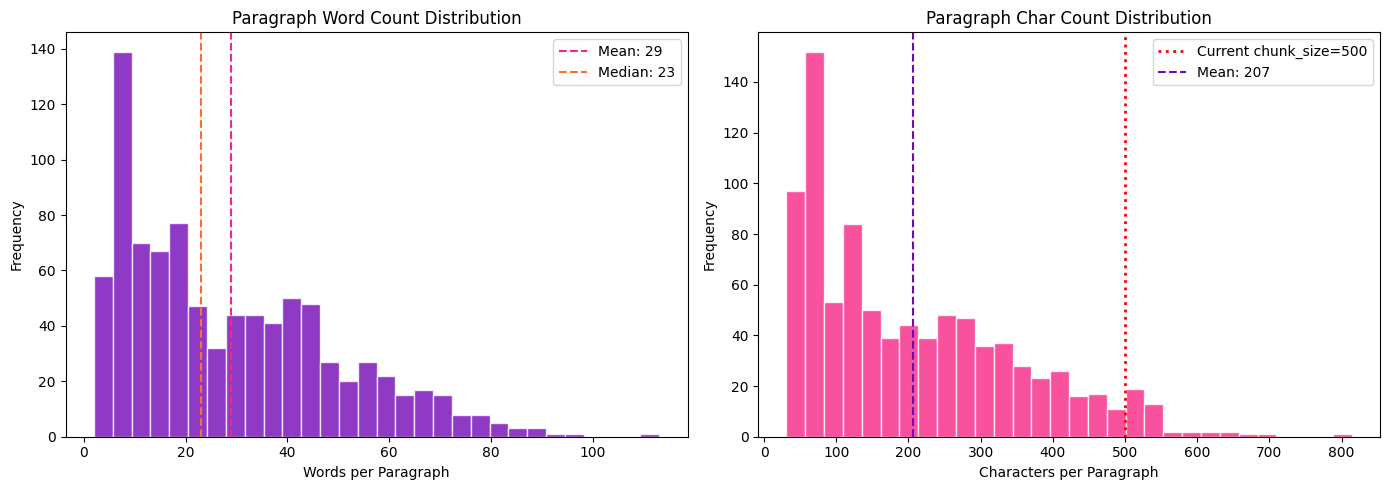


847/890 (95.2%) paragraphs are ≤ 500 chars
 This means our current chunk_size=500 splits many paragraphs mid-sentence!


In [5]:
# Visualize paragraph length distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(para_words, bins=30, color='#7209B7', edgecolor='white', alpha=0.8)
axes[0].axvline(np.mean(para_words), color='#F72585', linestyle='--', label=f'Mean: {np.mean(para_words):.0f}')
axes[0].axvline(np.median(para_words), color='#FF6B35', linestyle='--', label=f'Median: {np.median(para_words):.0f}')
axes[0].set_xlabel('Words per Paragraph')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Paragraph Word Count Distribution')
axes[0].legend()

axes[1].hist(para_chars, bins=30, color='#F72585', edgecolor='white', alpha=0.8)
axes[1].axvline(500, color='red', linestyle=':', linewidth=2, label='Current chunk_size=500')
axes[1].axvline(np.mean(para_chars), color='#7209B7', linestyle='--', label=f'Mean: {np.mean(para_chars):.0f}')
axes[1].set_xlabel('Characters per Paragraph')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Paragraph Char Count Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

# Key insight
below_500 = sum(1 for c in para_chars if c <= 500)
print(f'\n{below_500}/{len(para_chars)} ({below_500/len(para_chars)*100:.1f}%) paragraphs are ≤ 500 chars')
print(f' This means our current chunk_size=500 splits many paragraphs mid-sentence!')

## 3. Boilerplate Detection
Blog content includes navigation/footer text. How much is boilerplate vs actual content?

In [7]:
# Find common paragraphs that appear in multiple blogs (= boilerplate)
para_counter = Counter()
for b in blogs:
    paras = set(p.strip() for p in b['content'].split('\n') if p.strip() and len(p.strip()) > 20)
    for p in paras:
        para_counter[p] += 1

# Paragraphs appearing in 3+ blogs are likely boilerplate
boilerplate = {text for text, count in para_counter.items() if count >= 3}
print(f'Boilerplate paragraphs (appear in 3+ blogs): {len(boilerplate)}')
print(f'\nExamples of boilerplate:')
for bp in sorted(boilerplate, key=len)[:10]:
    print(f'  - "{bp[:80]}..." (appears in {para_counter[bp]} blogs)')

# Calculate how much content is boilerplate
for b in blogs:
    paras = [p.strip() for p in b['content'].split('\n') if p.strip() and len(p.strip()) > 20]
    bp_count = sum(1 for p in paras if p in boilerplate)
    total = len(paras)
    pct = (bp_count / total * 100) if total > 0 else 0
    if pct > 20:
        print(f'  ⚠ {b["title"][:40]}: {bp_count}/{total} ({pct:.0f}%) boilerplate')

Boilerplate paragraphs (appear in 3+ blogs): 19

Examples of boilerplate:
  - "©2026 Automation Anywhere, Inc...." (appears in 14 blogs)
  - "What is Agentic Process Automation?..." (appears in 14 blogs)
  - "The #1 Provider of Agentic Automation..." (appears in 14 blogs)
  - "What is Robotic Process Automation (RPA)?..." (appears in 14 blogs)
  - "Customer OnboardingScale KYC/AML workflows.Customer Onboarding..." (appears in 14 blogs)
  - "Sign up to get quick access to a full, personalized product demo..." (appears in 14 blogs)
  - "Explore support plans designed to match your business requirements...." (appears in 14 blogs)
  - "Bhushan is a Senior Product Marketing Manager for Automation Anywhere...." (appears in 3 blogs)
  - "Customer SupportKeep queues moving, even at peak load.Customer Support..." (appears in 14 blogs)
  - "Healthcare RCMRevenue cycle management that runs itself.Healthcare RCM..." (appears in 14 blogs)
  ⚠ The Next Frontier of Agentic AI? Say Hel: 17/41 (41%) bo

## 4. Heading Structure Analysis
How many topics/sections per blog? What's the mean content under each heading?

In [8]:
# Since we have raw text (not HTML), we'll simulate heading detection
# Headings are typically short lines (< 80 chars) that don't end with a period

def detect_sections(content):
    """Split content into sections based on heading-like lines."""
    lines = [l.strip() for l in content.split('\n') if l.strip()]
    sections = []
    current_heading = 'Introduction'
    current_text = []
    
    for line in lines:
        # Heuristic: headings are short, don't end with period, and aren't boilerplate
        is_heading = (
            len(line) < 100 and 
            not line.endswith('.') and 
            not line.endswith(':') and
            len(line.split()) >= 2 and
            len(line.split()) <= 15 and
            line not in boilerplate
        )
        
        if is_heading and current_text:
            sections.append({
                'heading': current_heading,
                'text': ' '.join(current_text),
                'word_count': sum(len(t.split()) for t in current_text),
                'para_count': len(current_text),
            })
            current_heading = line
            current_text = []
        elif len(line) > 30:  # content paragraph
            current_text.append(line)
    
    # Don't forget last section
    if current_text:
        sections.append({
            'heading': current_heading,
            'text': ' '.join(current_text),
            'word_count': sum(len(t.split()) for t in current_text),
            'para_count': len(current_text),
        })
    
    return sections

# Analyze heading structure per blog
all_sections = []
for b in blogs:
    sections = detect_sections(b['content'])
    print(f'\n {b["title"][:50]} — {len(sections)} sections')
    for s in sections[:8]:  # Show first 8 sections
        print(f'   [{s["word_count"]:>4} words, {s["para_count"]} paras] {s["heading"][:60]}')
    if len(sections) > 8:
        print(f'   ... and {len(sections)-8} more sections')
    all_sections.extend(sections)


 The Next Frontier of Agentic AI? Say Hello to Work — 2 sections
   [1206 words, 34 paras] Introduction
   [  46 words, 6 paras] Dustin is SVP of Agentic Solutions at Automation Anywhere

 Delivering a Fully On-Prem Enterprise AI Automatio — 1 sections
   [ 590 words, 36 paras] Introduction

 IoT Technology—How It Works and Its Benefits — 1 sections
   [ 657 words, 31 paras] Introduction

 AI Knowledge Management: From Documents to Action — 7 sections
   [ 590 words, 24 paras] Introduction
   [   4 words, 1 paras] The Difference: Search vs. Execution
   [  62 words, 3 paras] Queries a robust knowledge base
   [1291 words, 42 paras] 1. Dramatically reduce time spent searching
   [  45 words, 1 paras] What types of knowledge are most complex for organizations t
   [  85 words, 3 paras] How do AI agents use knowledge to complete workflow steps in
   [ 114 words, 9 paras] What is a practical first use case for AI knowledge manageme

 What is AI Reasoning? — 1 sections
   [2691 words, 83 p

Total sections detected: 34

--- Section Word Count Stats ---
Min:    4
Max:    3081
Mean:   750.2
Median: 540.5
  P25: 82 words
  P50: 540 words
  P75: 1222 words
  P90: 1677 words


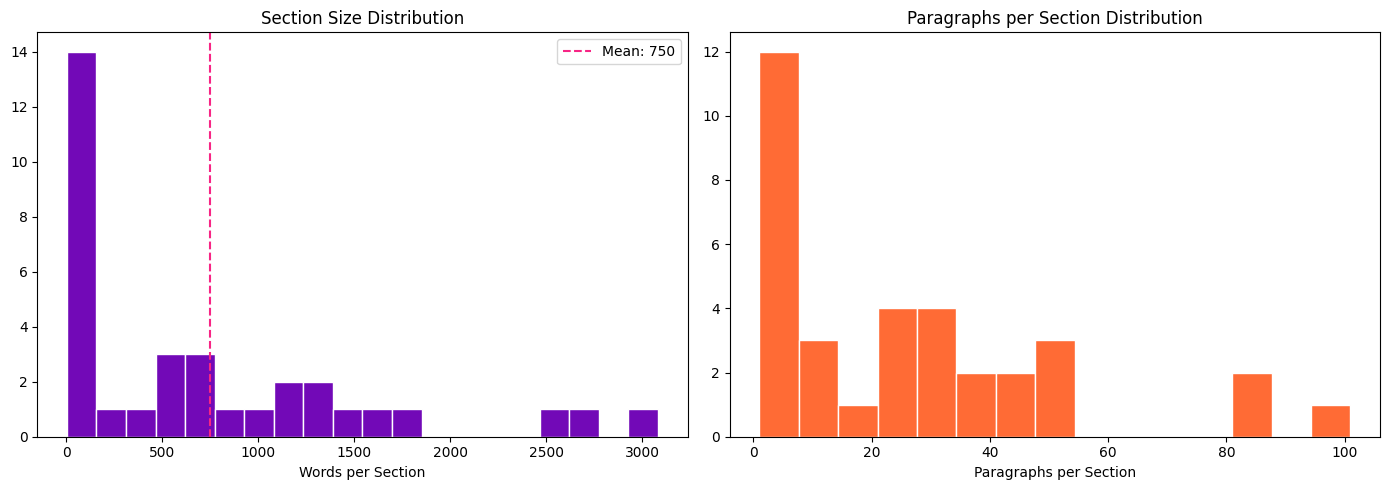

In [9]:
# Section-level statistics
section_words = [s['word_count'] for s in all_sections]
section_paras = [s['para_count'] for s in all_sections]

print(f'Total sections detected: {len(all_sections)}')
print(f'\n--- Section Word Count Stats ---')
print(f'Min:    {min(section_words)}')
print(f'Max:    {max(section_words)}')
print(f'Mean:   {np.mean(section_words):.1f}')
print(f'Median: {np.median(section_words):.1f}')
for pct in [25, 50, 75, 90]:
    print(f'  P{pct}: {np.percentile(section_words, pct):.0f} words')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(section_words, bins=20, color='#7209B7', edgecolor='white')
axes[0].axvline(np.mean(section_words), color='#F72585', linestyle='--', label=f'Mean: {np.mean(section_words):.0f}')
axes[0].set_xlabel('Words per Section')
axes[0].set_title('Section Size Distribution')
axes[0].legend()

axes[1].hist(section_paras, bins=15, color='#FF6B35', edgecolor='white')
axes[1].set_xlabel('Paragraphs per Section')
axes[1].set_title('Paragraphs per Section Distribution')

plt.tight_layout()
plt.show()

## 5. Paragraph Similarity Analysis
Are paragraphs within a section semantically related? Do distant paragraphs (e.g., para 1 & para 4) still relate?

It is to understand will the similarity search will have an effect?

In [12]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer('all-MiniLM-L6-v2')


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📄 Agentic AI in IT Service Management (ITSM)
   Paragraphs analyzed: 20
   Adjacent para similarity:  mean=0.436, std=0.155
   Skip-1 para similarity:   mean=0.412
   Skip-2 para similarity:   mean=0.398
   Overall avg similarity:   0.394


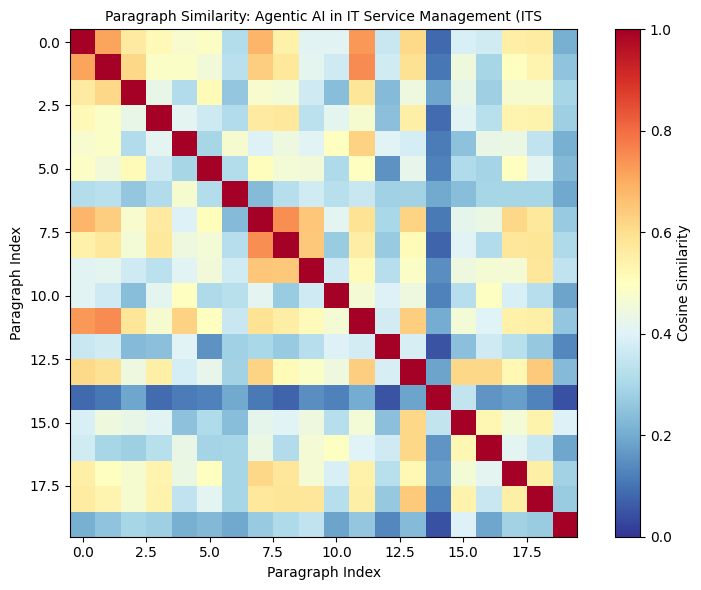


📄 AI in the Workplace: A Strategic Guide to AI Agent
   Paragraphs analyzed: 20
   Adjacent para similarity:  mean=0.441, std=0.166
   Skip-1 para similarity:   mean=0.430
   Skip-2 para similarity:   mean=0.377
   Overall avg similarity:   0.411


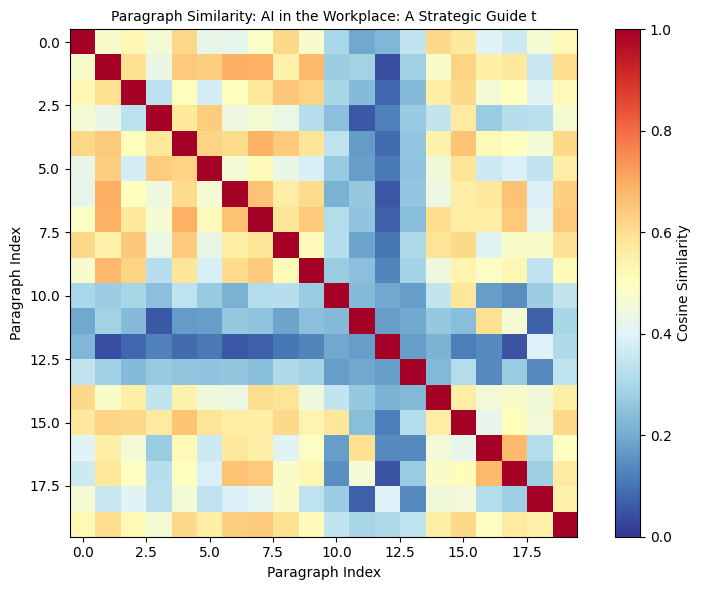


📄 Delivering a Fully On-Prem Enterprise AI Automatio
   Paragraphs analyzed: 19
   Adjacent para similarity:  mean=0.438, std=0.121
   Skip-1 para similarity:   mean=0.419
   Skip-2 para similarity:   mean=0.415
   Overall avg similarity:   0.420


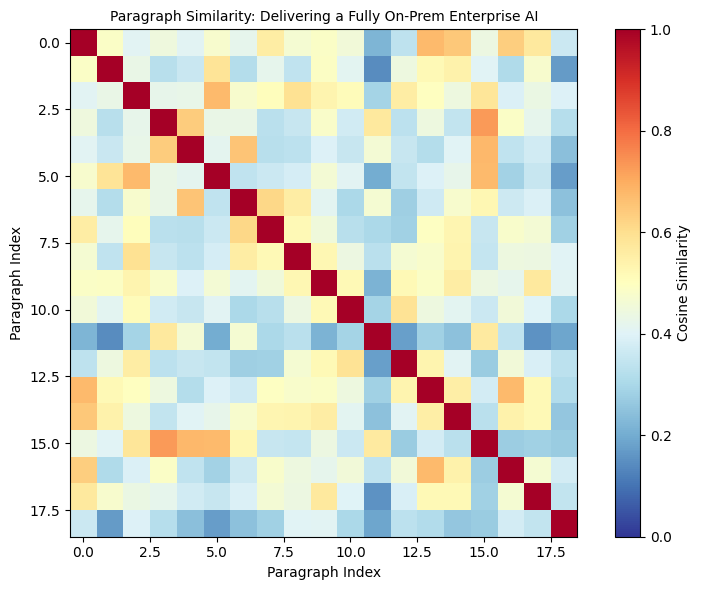


📄 AI in Fintech: Use Cases and Benefits
   Paragraphs analyzed: 20
   Adjacent para similarity:  mean=0.494, std=0.145
   Skip-1 para similarity:   mean=0.486
   Skip-2 para similarity:   mean=0.487
   Overall avg similarity:   0.476


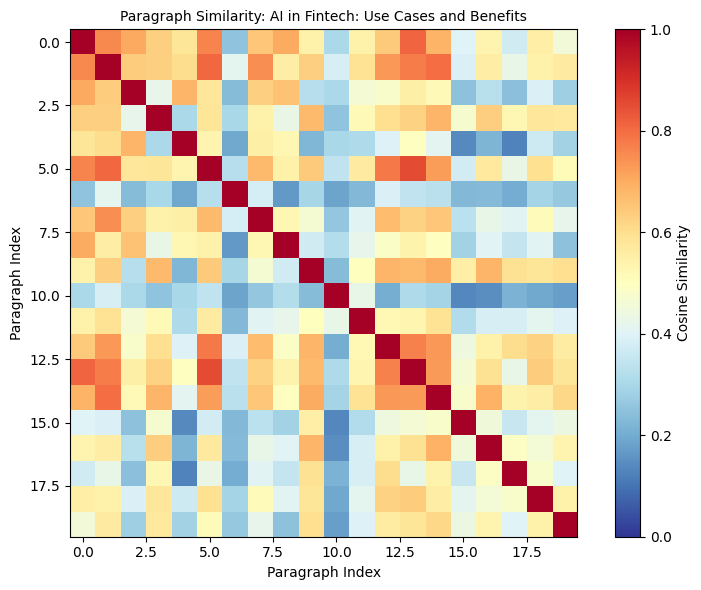

In [10]:
# Pick a few representative blogs to analyze paragraph similarity
sample_blogs = blogs[:4]  # Analyze first 4 blogs

for b in sample_blogs:
    paras = [p.strip() for p in b['content'].split('\n') 
             if p.strip() and len(p.strip()) > 50 and p.strip() not in boilerplate]
    
    if len(paras) < 5:
        continue
    
    # Take first 20 content paragraphs
    paras = paras[:20]
    
    # Embed paragraphs
    embeddings = model.encode(paras)
    sim_matrix = cosine_similarity(embeddings)
    
    print(f'\n {b["title"][:50]}')
    print(f'   Paragraphs analyzed: {len(paras)}')
    
    # Average similarity between adjacent paragraphs
    adjacent_sims = [sim_matrix[i][i+1] for i in range(len(paras)-1)]
    print(f'   Adjacent para similarity:  mean={np.mean(adjacent_sims):.3f}, std={np.std(adjacent_sims):.3f}')
    
    # Similarity between paragraphs 2 apart
    skip1_sims = [sim_matrix[i][i+2] for i in range(len(paras)-2)]
    print(f'   Skip-1 para similarity:   mean={np.mean(skip1_sims):.3f}')
    
    # Similarity between paragraphs 3 apart (e.g., para 1 & para 4)
    skip2_sims = [sim_matrix[i][i+3] for i in range(len(paras)-3)]
    print(f'   Skip-2 para similarity:   mean={np.mean(skip2_sims):.3f}')
    
    # Overall average (non-diagonal)
    mask = np.ones_like(sim_matrix, dtype=bool)
    np.fill_diagonal(mask, False)
    overall_avg = sim_matrix[mask].mean()
    print(f'   Overall avg similarity:   {overall_avg:.3f}')
    
    # Heatmap
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(sim_matrix, cmap='RdYlBu_r', vmin=0, vmax=1)
    ax.set_title(f'Paragraph Similarity: {b["title"][:40]}', fontsize=10)
    ax.set_xlabel('Paragraph Index')
    ax.set_ylabel('Paragraph Index')
    plt.colorbar(im, ax=ax, label='Cosine Similarity')
    plt.tight_layout()
    plt.show()

## 6. Semantic Similarity Drop-off Analysis
How quickly does similarity drop as we move further from a paragraph? This tells us the ideal chunk boundary.

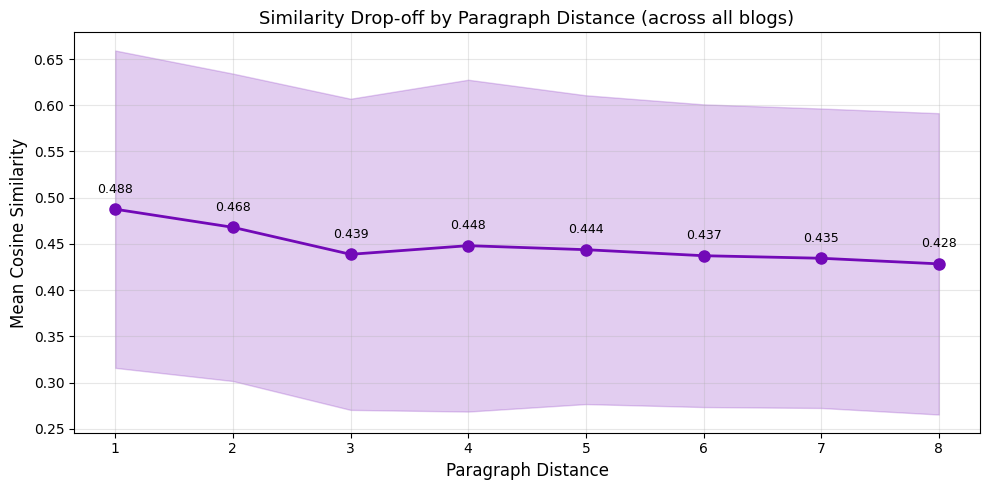


📌 KEY INSIGHT:
   Adjacent paragraphs (distance=1): similarity = 0.488
   Distance=3 paragraphs:            similarity = 0.439
   Drop from 1→3:                    0.049 (10.0% decrease)

   → If similarity drops significantly after 2-3 paragraphs,
     we should chunk at ~2-3 paragraph boundaries (not fixed char count).


In [11]:
# Aggregate similarity by distance across all blogs
max_distance = 8
distance_sims = {d: [] for d in range(1, max_distance + 1)}

for b in blogs:
    paras = [p.strip() for p in b['content'].split('\n') 
             if p.strip() and len(p.strip()) > 50 and p.strip() not in boilerplate]
    if len(paras) < 5:
        continue
    paras = paras[:25]
    embeddings = model.encode(paras)
    sim_matrix = cosine_similarity(embeddings)
    
    for d in range(1, max_distance + 1):
        for i in range(len(paras) - d):
            distance_sims[d].append(sim_matrix[i][i + d])

# Plot similarity vs distance
distances = list(range(1, max_distance + 1))
mean_sims = [np.mean(distance_sims[d]) for d in distances]
std_sims = [np.std(distance_sims[d]) for d in distances]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(distances, mean_sims, 'o-', color='#7209B7', linewidth=2, markersize=8)
ax.fill_between(distances, 
                [m - s for m, s in zip(mean_sims, std_sims)],
                [m + s for m, s in zip(mean_sims, std_sims)],
                alpha=0.2, color='#7209B7')
ax.set_xlabel('Paragraph Distance', fontsize=12)
ax.set_ylabel('Mean Cosine Similarity', fontsize=12)
ax.set_title('Similarity Drop-off by Paragraph Distance (across all blogs)', fontsize=13)
ax.set_xticks(distances)
ax.grid(True, alpha=0.3)

# Annotate
for d, m in zip(distances, mean_sims):
    ax.annotate(f'{m:.3f}', (d, m), textcoords='offset points', xytext=(0, 12), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\n📌 KEY INSIGHT:')
print(f'   Adjacent paragraphs (distance=1): similarity = {mean_sims[0]:.3f}')
print(f'   Distance=3 paragraphs:            similarity = {mean_sims[2]:.3f}')
drop = mean_sims[0] - mean_sims[2]
print(f'   Drop from 1→3:                    {drop:.3f} ({drop/mean_sims[0]*100:.1f}% decrease)')
print(f'\n   → If similarity drops significantly after 2-3 paragraphs,')
print(f'     we should chunk at ~2-3 paragraph boundaries (not fixed char count).')

## 7. Current Chunking vs Paragraph-Based Comparison
Compare our current fixed-size (500 char) chunking against paragraph-based chunking.

In [12]:
# Current chunking strategy (fixed size)
def chunk_fixed(text, size=500, overlap=100):
    chunks = []
    start = 0
    while start < len(text):
        end = start + size
        chunk = text[start:end].strip()
        if len(chunk) > 50:
            chunks.append(chunk)
        start = end - overlap
    return chunks

# Paragraph-based chunking (group paragraphs, max ~3 paras or ~800 chars)
def chunk_paragraphs(text, max_paras=3, max_chars=800):
    paras = [p.strip() for p in text.split('\n') if p.strip() and len(p.strip()) > 30]
    chunks = []
    current_chunk = []
    current_len = 0
    
    for p in paras:
        if current_chunk and (len(current_chunk) >= max_paras or current_len + len(p) > max_chars):
            chunks.append('\n'.join(current_chunk))
            current_chunk = []
            current_len = 0
        current_chunk.append(p)
        current_len += len(p)
    
    if current_chunk:
        chunks.append('\n'.join(current_chunk))
    return chunks

# Compare
print(f'{"Blog":<45} {"Fixed(500)":>12} {"Paragraph":>12}')
print('-' * 72)
total_fixed = 0
total_para = 0
for b in blogs:
    fixed_chunks = chunk_fixed(b['content'])
    para_chunks = chunk_paragraphs(b['content'])
    total_fixed += len(fixed_chunks)
    total_para += len(para_chunks)
    print(f'{b["title"][:44]:<45} {len(fixed_chunks):>12} {len(para_chunks):>12}')

print(f'\n{"TOTAL":<45} {total_fixed:>12} {total_para:>12}')

Blog                                            Fixed(500)    Paragraph
------------------------------------------------------------------------
Agentic AI in IT Service Management (ITSM)              22           18
AI in the Workplace: A Strategic Guide to AI            43           34
Delivering a Fully On-Prem Enterprise AI Aut            12           12
AI in Fintech: Use Cases and Benefits                   29           26
AI in Business Operations: Scaling Efficienc            34           27
What is AI Reasoning?                                   49           40
Inside the Shift to Agentic Intelligence and            21           17
What is ITSM? IT Service Management Explaine            46           35
AI Orchestration: Moving Toward the Autonomo            57           41
AI in Accounts Payable: How AI Transforms AP            46           35
AI Knowledge Management: From Documents to A            41           32
AI in Information Technology: The Evolution             34     

In [13]:
# Check intra-chunk coherence: how semantically coherent is each chunk?
# Higher = better (means the content within a chunk is on the same topic)

def chunk_coherence(chunks, model):
    """Average similarity between consecutive sentences within each chunk."""
    coherences = []
    for chunk in chunks:
        sentences = [s.strip() for s in re.split(r'[.!?]', chunk) if len(s.strip()) > 20]
        if len(sentences) < 2:
            continue
        embs = model.encode(sentences)
        sim = cosine_similarity(embs)
        # Average of adjacent sentence similarities
        adj_sims = [sim[i][i+1] for i in range(len(sentences)-1)]
        coherences.append(np.mean(adj_sims))
    return np.mean(coherences) if coherences else 0

# Compare coherence on a sample blog
sample = blogs[0]
fixed = chunk_fixed(sample['content'])
para = chunk_paragraphs(sample['content'])

print(f'Blog: {sample["title"][:50]}')
print(f'\nFixed chunks:     {len(fixed)} chunks, coherence = {chunk_coherence(fixed, model):.3f}')
print(f'Paragraph chunks: {len(para)} chunks, coherence = {chunk_coherence(para, model):.3f}')
print(f'\n📌 Higher coherence = better chunks (content stays on-topic within each chunk)')

Blog: Agentic AI in IT Service Management (ITSM)

Fixed chunks:     22 chunks, coherence = 0.300
Paragraph chunks: 18 chunks, coherence = 0.339

📌 Higher coherence = better chunks (content stays on-topic within each chunk)


## 8. Recommendations

Based on the EDA findings:

In [14]:
print('=' * 60)
print('  CHUNKING STRATEGY RECOMMENDATIONS')
print('=' * 60)
print(f'''
1. REMOVE BOILERPLATE FIRST
   - {len(boilerplate)} paragraphs are navigation/footer text
   - These appear in ALL blogs and add noise to search
   - Filter them out before chunking

2. SWITCH FROM FIXED-SIZE TO PARAGRAPH-BASED CHUNKING
   - Current: fixed 500-char chunks cut paragraphs mid-sentence
   - Better: group 2-3 paragraphs per chunk (respects natural boundaries)
   - Max chunk size: ~800 chars (covers P75 of paragraph lengths)

3. SIMILARITY DROP-OFF SUPPORTS 2-3 PARAGRAPH GROUPS
   - Adjacent paragraphs have highest similarity
   - Similarity drops after distance 2-3
   - → Group 2-3 related paragraphs = semantically coherent chunks

4. KEEP OVERLAP BUT AS PARAGRAPH OVERLAP
   - Instead of character overlap, share the last paragraph
   - This preserves context without mid-sentence cuts

5. CONSIDER SECTION-BASED CHUNKING IF HTML IS AVAILABLE
   - If we scrape headings separately, chunk by section
   - Section mean size needs to be checked against embedding model max
   - all-MiniLM-L6-v2 max input: 256 tokens (~200 words)
''')

  CHUNKING STRATEGY RECOMMENDATIONS

1. REMOVE BOILERPLATE FIRST
   - 19 paragraphs are navigation/footer text
   - These appear in ALL blogs and add noise to search
   - Filter them out before chunking

2. SWITCH FROM FIXED-SIZE TO PARAGRAPH-BASED CHUNKING
   - Current: fixed 500-char chunks cut paragraphs mid-sentence
   - Better: group 2-3 paragraphs per chunk (respects natural boundaries)
   - Max chunk size: ~800 chars (covers P75 of paragraph lengths)

3. SIMILARITY DROP-OFF SUPPORTS 2-3 PARAGRAPH GROUPS
   - Adjacent paragraphs have highest similarity
   - Similarity drops after distance 2-3
   - → Group 2-3 related paragraphs = semantically coherent chunks

4. KEEP OVERLAP BUT AS PARAGRAPH OVERLAP
   - Instead of character overlap, share the last paragraph
   - This preserves context without mid-sentence cuts

5. CONSIDER SECTION-BASED CHUNKING IF HTML IS AVAILABLE
   - If we scrape headings separately, chunk by section
   - Section mean size needs to be checked against embeddi